## Users activity analysis

### Raw data 
whit the help of pandas now the *"product_activity.csv"* is now ready to be manipulated and transform in data that we can use to do our own metrics

In [84]:
import pandas as pd

# read the data set:
raw_data_df = pd.read_csv("product_activity.csv")

# show the first 5 rows
display(raw_data_df.head())


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile


### Initial analysis

In [85]:
# initial information description of the df
raw_data_description = pd.DataFrame(raw_data_df.describe(include="all"))
display(raw_data_description)

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
count,8782,8782,8782,8782,8028.000000,8782,8782,8782,8782.000000,8782.000000,8782.000000,8782
unique,2010,2010,10,19,NaN,8610,53,8609,NaN,NaN,NaN,6
top,U00087,2024-01-08T12:18:18,US,free,NaN,P0002865,tech,2024-02-14T15:55:59,NaN,NaN,NaN,web
freq,40,40,1928,5978,NaN,2,1187,3,NaN,NaN,NaN,4416
mean,NaN,NaN,NaN,NaN,27.902591,NaN,NaN,NaN,6.918356,8.324186,29.479390,NaN
std,NaN,NaN,NaN,NaN,7.547052,NaN,NaN,NaN,5.127311,6.754906,36.819928,NaN
min,NaN,NaN,NaN,NaN,16.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,22.000000,NaN,NaN,NaN,3.000000,4.000000,5.000000,NaN
50%,NaN,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,6.000000,6.000000,17.000000,NaN
75%,NaN,NaN,NaN,NaN,33.000000,NaN,NaN,NaN,9.000000,11.000000,40.000000,NaN


One can see that at first everything seems normal, but already here we can see that days_since_signup, created_at, post_created_at have the wrong format, they are not datetime nor timestamp, in the case of created_at and post_created_at, this two are plain text, since none of them have min, max, mean, etc. Then we hace daus_since_signup that it is also not datetime, or timestamp, but it a float or integer.

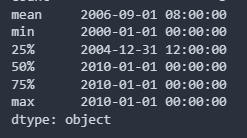

This is an example. In the case of the dates this is how it would had showd if it was in the correct format

### .info() on the raw_data_df

In [86]:
raw_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


We can see better now how created_at, post_created_at, and days_since_signup are not the correct type. So there we have our first problem with the data set. Other things that i can se with this information is that the user_age non-null count is lower than the other rows, that means that there is at least one user with no age registered, or in other case for some reason age its being eliminated along the way

### looking into the str type columns
We have three columns plan_type, post_category, device_type. this ones are stricly str so i can be errors in the values if users are able to put the value themselfs

In [87]:
unique_values_frec_type = raw_data_df.plan_type.describe()
display(unique_values_frec_type)

unique_values_frect_category = raw_data_df.post_category.describe()
display(unique_values_frect_category)

unique_values_frect_devices = raw_data_df.device_type.describe()
display(unique_values_frect_devices)

count     8782
unique      19
top       free
freq      5978
Name: plan_type, dtype: object

count     8782
unique      53
top       tech
freq      1187
Name: post_category, dtype: object

count     8782
unique       6
top        web
freq      4416
Name: device_type, dtype: object

We can see here that the unique count is high specially in the plan_type column, there is probably some work to be done here, as well as see if the problems are so deep that some rows would have to go to cuarentine. Almost 50% of the user_base comes from the web app, that is something to check if its true, and almost everyone is on the free plan.

## Canonic Normalization
To resolve the isues with the columns plan_type, post_category, device_type, first we do a cleaning with the suposed list of values that could have each row 


In [88]:
# lists of values

plan_type = ['free', 'pro', 'enterprise']
device_type = ['web', 'mobile', 'desktop']
post_category = ['tech', 'life',  'sports', 'science', 'finance', 'gaming', 'music', 'health', 'education', 'travel']

# in any case, i want to take a look in to the actual unique values of each column
print(raw_data_df.plan_type.unique())
print(raw_data_df.post_category.unique())
print(raw_data_df.device_type.unique())

# in contex this is the lenght of the raw and the supose one
print(f'plan_type : raw = {raw_data_df.plan_type.nunique()}, regular = {len(plan_type)}')
print(f'device_type : raw = {raw_data_df.device_type.nunique()}, regular = {len(device_type)}')
print(f'post_category : raw = {raw_data_df.post_category.nunique()}, regular = {len(post_category)}')

<StringArray>
[         'pro',         'free',         'Pro ',          'PRo',
   'enterprise',         'Free',        ' pro ',         'FREE',
         'FreE',   'ENTERPRISE',   'EnterPrise',       ' free ',
 ' enterprise ',          'PRO',          'Pro',   'Enterprise',
      'premium',          'vip',  'enterprise+']
Length: 19, dtype: str
<StringArray>
[    ' sport ',        'tech',     'finance',   'education',        'life',
      'health',   ' science ',        'TECH',     'science',       'Music',
      'gaming', ' education ',       'music',     'FINANCE',      'sports',
    ' travel ',      'travel',      ' tech ',     'sciense',      'GAMING',
        'Tech',      'Health',     'finanse',     'gamming',      'SPORTS',
     'Finance',     'Science',        'Life',       'MUSIC',   'EDUCATION',
      'trvael',    ' gaming ',         'lfe',        'LIFE',        'tehc',
      'HEALTH',    ' health ',     ' music ',   'Education',     'SCIENCE',
      'Sports',        'musc',  

not only there is a lot of static in this data set some of them had to be atributed to accidental espaces in the text, this is something that it has to be told to the front team 

In [89]:
# cleaning this mess
raw_data_df['quarantine_reason'] = ""

#with this we can clean the rows that are still salvable
for element in ['plan_type', 'post_category', 'device_type']:
    raw_data_df[element] = raw_data_df[element].str.strip().str.lower()

# try to parse the dates
created_at_dates = pd.to_datetime(raw_data_df["created_at"], errors='coerce')
post_created_at_dates = pd.to_datetime(raw_data_df["post_created_at"], errors='coerce')

# bool list of dates that cannot be parse
errors_in_parse = (created_at_dates.isna() & raw_data_df["created_at"].notna()) | (post_created_at_dates.isna() & raw_data_df["post_created_at"].notna())

# dates that does not make sense
mismatch_dates = post_created_at_dates < created_at_dates

# bool list of duplicated rows
duplicated_rows = raw_data_df.duplicated(keep='first')

#now we see with ones are bad 
bad_element_plan_type = ~raw_data_df.plan_type.isin(plan_type)
bad_element_post_category = ~raw_data_df.post_category.isin(post_category)
bad_element_device_type = ~raw_data_df.device_type.isin(device_type)

#now we put why the row is going to quarantine 
raw_data_df.loc[errors_in_parse, "quarantine_reason"] += "Unable to parse to datetime; "
raw_data_df.loc[mismatch_dates, "quarantine_reason"] += "time between login and post does not make sense; "
raw_data_df.loc[duplicated_rows, "quarantine_reason"] += "the row is duplicated in data set; "
raw_data_df.loc[bad_element_plan_type, "quarantine_reason"] += "incorrect value of plan_type; "
raw_data_df.loc[bad_element_post_category, "quarantine_reason"] += "incorrect value of post_category; "
raw_data_df.loc[bad_element_device_type, "quarantine_reason"] += "incorrect value of device_type; "

#segmentation of data
clean_data_df = raw_data_df[raw_data_df["quarantine_reason"] == ""].copy()
quarantine_data_df = raw_data_df[raw_data_df.quarantine_reason != ""].copy()

#drop the quarantine_reason column in clean_data since no data is going there (i hope)
clean_data_df.drop(columns=["quarantine_reason"], inplace=True)

#Parse the date for real this time 
clean_data_df["created_at"] = pd.to_datetime(clean_data_df["created_at"])
clean_data_df["post_created_at"] = pd.to_datetime(clean_data_df["post_created_at"])

#now with the correct dates calculate the new time_sice_signup
clean_data_df["time_since_signup_calc"] = (clean_data_df.post_created_at - clean_data_df.created_at).dt.days


With all this proccess now we have tu segmentations of data, one with the clean data, and other with the data that went to quarantine,now is time to pass it to csv format


In [90]:
# CSV format clean data
clean_data_df.to_csv("clean_product_activity.csv", index=False)
# CSV format quarantine data
quarantine_data_df.to_csv("quarantine_product_activity.csv", index=False)

#head of clean_data_df
display(clean_data_df.head(10))
#head of quarantine_data_df
display(quarantine_data_df.head(10))

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,time_since_signup_calc
1,U00236,2025-06-22 07:49:10,BR,free,27.0,P0001023,tech,2025-09-13 20:31:06,1,9,83,web,83
2,U00791,2024-02-12 02:45:45,CL,free,28.0,P0003405,tech,2024-02-14 05:17:48,11,2,2,mobile,2
3,U01522,2024-09-22 07:06:50,US,free,16.0,P0006524,finance,2024-09-24 07:51:34,5,2,2,web,2
4,U01092,2025-07-18 02:27:52,PY,free,NaN,P0004665,education,2025-07-24 04:56:56,7,2,6,mobile,6
5,U00488,2025-03-19 16:56:05,US,free,43.0,P0002030,finance,2025-03-28 12:10:25,3,10,9,web,8
6,U00480,2024-07-29 02:09:07,US,free,26.0,P0002003,life,2024-08-27 10:38:58,5,6,29,web,29
7,U01863,2024-12-12 21:40:02,CL,free,31.0,P0008000,health,2025-02-02 21:09:32,5,5,52,mobile,51
8,U00819,2024-04-26 02:18:59,BR,free,26.0,P0003544,health,2024-07-28 05:48:12,1,29,93,mobile,93
9,U00880,2024-12-12 23:03:33,UY,free,32.0,P0003784,science,2024-12-19 17:52:17,7,2,7,mobile,6
10,U00640,2024-09-19 05:48:36,MX,pro,35.0,P0002645,tech,2024-09-26 10:26:37,8,15,7,mobile,7


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,quarantine_reason
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile,incorrect value of post_category;
22,U01754,2025-01-17T07:05:21,US,free,39.0,P0007502,sports,2024-12-18T16:05:21,3,6,0,web,time between login and post does not make sense;
43,U00087,2024-01-08T12:18:18,ES,free,23.0,P0000347,sciense,2024-03-12T08:48:31,3,39,64,web,incorrect value of post_category;
87,U01512,2024-05-09T10:17:35,BR,free,17.0,P0006474,finanse,2024-05-31T18:32:45,11,9,22,desktop,incorrect value of post_category;
91,U00371,2024-07-14T02:43:36,AR,free,NaN,P0001624,gamming,2024-07-15T21:11:18,1,2,1,web,incorrect value of post_category;
131,U01415,2024-12-24T07:16:48,UY,pro,30.0,P0006033,trvael,2024-12-28T17:42:17,2,10,4,mobile,incorrect value of post_category;
142,U01754,2025-01-17T07:05:21,US,free,39.0,P0007503,lfe,2025-01-26T13:53:23,6,6,9,web,incorrect value of post_category;
164,U00813,2024-08-15T23:29:10,BR,free,18.0,P0003499,tehc,2024-09-04T13:51:13,12,11,20,mobile,incorrect value of post_category;
170,U00707,2024-10-07T17:32:12,MX,pro,27.0,P0003002,gaming,2024-09-27T12:32:12,13,11,0,mobile,time between login and post does not make sense;
204,U00503,2025-01-13T13:27:33,US,free,16.0,P0002095,health,2024-12-14T01:27:33,7,9,0,web,time between login and post does not make sense;


with the data now in their respective CSVs now i can start analysing the data more slowly, 


In [189]:
# difference with the raw data
total_mismatch = 0 
for element in mismatch_dates:
    if element == True:
        total_mismatch += 1


metrics_data_df = pd.DataFrame({
    "Metrics" : [
        "total raw data",
        "total clean data",
        "total quarantine data",
        "% of clean data",
        "% of quarantine data",
        "% of mismatch in dates"
    ],
    "values" : [
        round(len(raw_data_df)),
        round(len(clean_data_df)),
        round(len(quarantine_data_df)),
        f"{(len(clean_data_df) * 100) / len(raw_data_df)}%",
        f"{(len(quarantine_data_df) * 100) / len(raw_data_df)}%",
        f"{(total_mismatch * 100) / len(raw_data_df)}%"
    ]
})

display(metrics_data_df)
metrics_data_df.to_csv("metrics_summary.csv", index=False)

,Metrics,values
0,total raw data,8782
1,total clean data,8161
2,total quarantine data,621
3,% of clean data,92.92871783192895%
4,% of quarantine data,7.071282168071054%
5,% of mismatch in dates,1.1386927806877705%


there is a aprox 93% of clean data in the raw data, this without taking in count the % of values that were having problems like spaces and upper casses, in any case, it is acceptable, for now, the quarantine data is 7% that dont seems like much but still counts, there were mismatches and that is a problem, if we havent catch it in time that would have been a large bias

## Metrics and Analysis


### Distribution
gonna take a look to the users per plan as well as the post per country, category and device

In [100]:
#user per plan 
user_per_plan_count = clean_data_df.groupby('plan_type')["user_id"].nunique()
user_per_plan_count_df = user_per_plan_count.reset_index()
user_per_plan_count_df.columns = ["plan_type", "user_count"]
display(user_per_plan_count_df)

,plan_type,user_count
0,enterprise,82
1,free,1532
2,pro,362


As it was seen comming "free" is the type of plan that most of the users seems to use, but something that is rare is that we have less that 100 "enterprise" users.

In [ ]:
#post per country
post_per_country = clean_data_df.groupby('country')["post_id"].nunique()
post_per_country_df = post_per_country.reset_index()
post_per_country_df.columns = ["country", "posts_count"]
#order country by their post count
display(post_per_country_df.sort_values(by=["posts_count"], ascending=False))

,country,posts_count
8,US,1803
1,BR,1526
0,AR,1123
7,PY,799
5,MX,772
2,CL,533
4,ES,524
3,CO,463
6,PE,378
9,UY,240


we have a stable user base in the top three, but there is a lot to be done with the last 3, below 500 is a problem, have to take a look on it later

In [108]:
# post per category 
post_per_category = clean_data_df.groupby('post_category')["post_id"].nunique()
post_per_category_df = post_per_category.reset_index()
post_per_category_df.columns = ['category', 'post_count']
display(post_per_category_df.sort_values(by=["post_count"], ascending=False))

,category,post_count
8,tech,1333
4,life,1013
7,sports,941
6,science,828
1,finance,824
2,gaming,794
5,music,657
0,education,650
3,health,645
9,travel,476


tech is the category with the most post by more than 300 posts, its a lot if its compared with the rest of categories that are, at most, 100 post apart

In [109]:
#post per device
post_per_device = clean_data_df.groupby('device_type')["post_id"].nunique()
post_per_device_df = post_per_device.reset_index()
post_per_device_df.columns = ['device_type', 'post_count']
display(post_per_device_df.sort_values(by=["post_count"], ascending=False))

,device_type,post_count
2,web,4099
1,mobile,3498
0,desktop,564


the way i see this is that we can put less resources into desktop type devices, or move the platform to a PWA format, this because it does not seem to be afortable to continue develop of desktop native application, between mobile and desktop alone are almost 3000 posts, but need more information for that

## Engagement

Now its time to start looking into votes per plan, country, category and divices

In [133]:
# votes per plan 
votes_per_plan = clean_data_df.groupby('plan_type')["votes_received"].describe()
votes_per_plan_df = votes_per_plan.reset_index()
votes_per_plan_df.columns = ["plan_type", "count", "mean", "std", "min", "25%", "50%", "75%", "max"]
display(votes_per_plan_df)


,plan_type,count,mean,std,min,25%,50%,75%,max
0,enterprise,322.0,7.590062,4.912280,0.0,4.0,7.0,10.0,26.0
1,free,6290.0,6.676948,4.914495,0.0,3.0,6.0,9.0,43.0
2,pro,1549.0,7.677211,5.501621,0.0,4.0,7.0,10.0,50.0


here we can se that the votes concentrate arrown the free plan, but the max votes in a post came from a post made by a pro user, so there is more to it, enterprise as expected have the lowest count of votes, but the mean of votes per user is almost like a pro user, the reality is probably that the free user are more casual users than the core users of the application, so that would explain why the median of the enterprise and pro users votes is higher than the free users. Also the value of the post of pro users is the highest with 5.5 std, that further proves the point.

In [135]:
votes_per_country = clean_data_df.groupby('country')["votes_received"].describe()
votes_per_country_df = votes_per_country.reset_index()
votes_per_country_df.columns = ['country', 'count', "mean", "std", "min", "25%", "50%", "75%", "max"]
display(votes_per_country_df.sort_values(by=["count"], ascending=False))

,country,count,mean,std,min,25%,50%,75%,max
8,US,1803.0,6.978369,5.078199,0.0,3.00,6.0,9.0,33.0
1,BR,1526.0,6.913499,5.160162,0.0,3.00,6.0,9.0,50.0
0,AR,1123.0,6.754230,4.883506,0.0,3.00,6.0,9.0,48.0
7,PY,799.0,6.558198,4.741308,0.0,3.00,6.0,9.0,32.0
5,MX,772.0,6.932642,5.203573,0.0,3.00,6.0,9.0,39.0
2,CL,533.0,7.335835,5.105077,0.0,4.00,6.0,10.0,30.0
4,ES,524.0,6.988550,4.866857,0.0,3.00,6.0,10.0,27.0
3,CO,463.0,7.207343,5.473291,0.0,3.00,6.0,10.0,34.0
6,PE,378.0,6.537037,4.993359,0.0,3.00,6.0,9.0,32.0
9,UY,240.0,6.854167,4.763835,0.0,3.75,6.0,9.0,27.0


all countries are balanced in votes, if i have to say something is that US, BR, AR are not that diffrent of the other countries, they happend to be winning in votes because of brute force, meanwhile MX has less vote counts that the three but have more meaningful stats that them.

In [136]:
# votes per category 
votes_per_category = clean_data_df.groupby('post_category')["votes_received"].describe()
votes_per_category_df = votes_per_category.reset_index()
votes_per_category_df.columns = ['category', 'count', "mean", "std", "min", "25%", "50%", "75%", "max"]
display(votes_per_category_df.sort_values(by=["count"], ascending=False))

,category,count,mean,std,min,25%,50%,75%,max
8,tech,1333.0,7.693923,5.294419,0.0,4.0,7.0,10.0,38.0
4,life,1013.0,6.191510,4.311815,0.0,3.0,5.0,8.0,31.0
7,sports,941.0,6.579171,4.761476,0.0,3.0,6.0,9.0,30.0
6,science,828.0,7.576087,5.792900,0.0,4.0,6.0,10.0,48.0
1,finance,824.0,6.856796,5.166617,0.0,3.0,6.0,9.0,50.0
2,gaming,794.0,7.177582,5.116297,0.0,4.0,6.0,9.0,33.0
5,music,657.0,6.284627,4.687128,0.0,3.0,5.0,9.0,32.0
0,education,650.0,6.800000,5.166563,0.0,3.0,6.0,9.0,43.0
3,health,645.0,6.471318,4.550394,0.0,3.0,6.0,9.0,28.0
9,travel,476.0,6.869748,5.154849,0.0,3.0,6.0,9.0,34.0


indeed tech is the king of traffic in the site, it is the highest in almost everythin except in 75% were it shares the top with science, and max votes, that podium goes to finance, but something that is to note, travel has a lot of engagement as well, despite its few posts its stats are against the top ones.

In [ ]:
#votes per device
votes_per_device = clean_data_df.groupby('device_type')["votes_received"].describe()
votes_per_device_df = votes_per_device.reset_index()
votes_per_device_df.columns = ['device_type', 'count', "mean", "std", "min", "25%", "50%", "75%", "max"]
display(votes_per_device_df.sort_values(by=["count"], ascending=False))

,device_type,count,mean,std,min,25%,50%,75%,max
2,web,4099.0,6.964382,5.122292,0.0,3.0,6.0,9.0,50.0
1,mobile,3498.0,6.806461,4.968933,0.0,3.0,6.0,9.0,33.0
0,desktop,564.0,7.053191,4.981387,0.0,4.0,6.0,10.0,38.0


despite beening less desktop users it seams that their post are the ones that are made by the most of the 1% of users, because its a high contrast and it still is the second best ahead of mobile and only down of web by its std and max

## Averages and Interpretation

calculate the mean of posts per plan and post per user

In [149]:
# one again the mean of votes per plan 
post_per_plan_mean = clean_data_df.groupby('plan_type')['votes_received'].mean()
post_per_plan_mean_df = post_per_plan_mean.reset_index()
post_per_plan_mean_df.columns = ['plan_type', 'votes_received_mean']
display(post_per_plan_mean_df)


post_per_user_mean = clean_data_df.groupby('user_id')['post_id'].nunique().mean()
post_per_user_mean_df = pd.DataFrame({
    "metric" : [
        "user_mean_post"
    ],
    "value" : [
        post_per_user_mean
    ]
})
display(post_per_user_mean_df)

,plan_type,votes_received_mean
0,enterprise,7.590062
1,free,6.676948
2,pro,7.677211


,metric,value
0,user_mean_post,4.130061


the mean of votes received per plan_type is high while, the user_mean_post is lower than the votes, that is normal, users tipicaly tent to use apps to pass the time and only fewer make posts, so is only normal that the amount of mean votes received per plan type is higher than the mean post made by users. The top 1% of users is the responsable of the mayority of posts so thats one other part of the puzzle

## Event vs User

so now its time to calculate the votes per row and the votes per user, see how they differ

In [185]:
mean_votes_per_row = clean_data_df.votes_received.mean()
mean_votes_per_user = clean_data_df.groupby("user_id")["votes_received"].max().mean()

mean_votes_per_row_and_user_df = pd.DataFrame({
    "metrics" : [
        "mean_votes_per_row",
        "mean_votes_per_user"
    ],
    "values" : [
        mean_votes_per_row.round(2),
        mean_votes_per_user.round(2)
    ]
})

display(mean_votes_per_row_and_user_df)

,metrics,values
0,mean_votes_per_row,6.90
1,mean_votes_per_user,11.16


in this case they differ because i, not only group by user_id the votes, i selected the post that had the most votes per user, so because there is feawer data and the conditions arent the same, they differ by almost 5 digits. 

## Concentration and Temporality

% of posts and votes that comes from the top 1% of users. 
My top % of users would be the ones that have more than the mean of post_created, days_since_signup, votes_received

In [188]:
# ill find my 1% fist

users = clean_data_df.groupby('user_id')[['user_total_posts', 'votes_received', 'days_since_signup']].max()
user_df = users.reset_index()
user_df.columns = ['user_id', 'user_total_posts', 'votes_received', 'days_since_signup']

# now i have the best of them at top
user_df_sorted = user_df.sort_values(by=['user_total_posts', 'votes_received', 'days_since_signup'], ascending=False)

# the 1%
top_1_users = int(len(user_df_sorted) * 0.01)

# separate the 1%
top_one_users_df = user_df_sorted.head(top_1_users)

display(top_one_users_df)



,user_id,user_total_posts,votes_received,days_since_signup
85,U00087,39,21,239
956,U00967,38,18,404
875,U00885,35,33,262
1820,U01843,31,24,188
809,U00819,29,16,140
509,U00516,28,15,145
770,U00780,27,27,121
996,U01008,26,34,135
1146,U01158,25,22,152
263,U00267,25,22,148


this users are most responsable for the important activity in the page, 

In [178]:
posts_user_one = top_one_users_df.user_total_posts.sum()
votes_user_one = top_one_users_df.votes_received.sum()
total_posts = clean_data_df.post_id.nunique()
total_votes = clean_data_df.groupby('user_id')['votes_received'].max().sum()

# % of posts that comes from the top users
final_perc_post_user = (posts_user_one * 100) / total_posts

# % of votes that comes form the top users
final_perc_votes_users = (votes_user_one * 100) / total_votes

top_users_metrics_df = pd.DataFrame({
    "metrics" : [
        "% of votes from top 1% users",
        "% of posts from top 1% users"
    ],
    "values" : [
        final_perc_votes_users,
        final_perc_post_user
    ]
})

display(top_users_metrics_df)

,metrics,values
0,% of votes from top 1% users,1.737513
1,% of posts from top 1% users,6.114447


with this we can confirm that the page is not been run only by its one percent users, and has a healty user base

## Tendencies

In [182]:
#activity and engagement for month
trend_monthly = clean_data_df.resample('ME', on="post_created_at").agg({
    'post_id' : 'nunique',
    'votes_received' : 'sum'
}).reset_index()

trend_monthly.columns = ['Month', 'total_posts', 'total_votes']

display(trend_monthly)

,Month,total_posts,total_votes
0,2024-01-31,189,1341
1,2024-02-29,354,2477
2,2024-03-31,362,2417
3,2024-04-30,382,2648
4,2024-05-31,435,2973
5,2024-06-30,372,2457
6,2024-07-31,363,2608
7,2024-08-31,376,2534
8,2024-09-30,296,1963
9,2024-10-31,336,2454


With this last metrics of tendencies for month we can see that it seems that the page is healty, at first look nothing is wrong

In [184]:
#activity and engagement for week
trend_weekly = clean_data_df.resample('W', on="post_created_at").agg({
    'post_id' : 'nunique',
    'votes_received' : 'sum'
}).reset_index()

trend_weekly.columns = ['Week', 'total_posts', 'total_votes']

display(trend_weekly)

,Week,total_posts,total_votes
0,2024-01-07,10,57
1,2024-01-14,27,164
2,2024-01-21,57,464
3,2024-01-28,66,462
4,2024-02-04,63,432
...,...,...,...
100,2025-12-07,85,541
101,2025-12-14,84,649
102,2025-12-21,80,521
103,2025-12-28,88,600


It has to be said that sometimes it spikes to highs of votes that seems rare, this can be because of bots and might have to take a look later

## Product Decisions (based in evidence)

### Segment to prioritize
I would propose prioritizing the latest data segmentation, the one that tracks monthly and weekly trends. This is to ensure the growth, or at least the integrity, of posts and votes. It's possible to observe an increase in posts but a decrease in votes, which could be due to spam or users leaving because of the quality of the posts.

### Column that was misleading in the uncleaned dataset
When I started cleaning the dataset we were given, I noticed that the column calculating the time between the first login and user posts occasionally produced data that simply didn't make sense and required cleaning or quarantining. This column caused me the most problems. The *"post_category"*, *"plan_type"*, and *"device_type"* columns also had errors that couldn't simply be cleaned; instead, they were values ​​that directly sent the row to quarantine.

### Data to add to the tracking
To the upcoming datasets, I would add *'total_votes_given'* from users to better calculate the impact of the top 1% of users on the site, so we can know exactly how much they influence site activity. I would also add *'session_time'* to measure the average time all users spend on the site, all for better data collection.

## Proposed actions

### The datasets being sent right now, based on the one we have now, give us a picture of the current data quality, which is quite poor.

The two actions I propose to improve the quality of the data sets submitted from now on are: first, to add better controls for the allowed formats of *"post_category"*, *"plan_type"*, and *"device_type"* to increase data integrity; and second, to use a single date format for *"created_at"* and *"post_created_at"* to reduce errors when parsing to datetime later. Finally, I propose that rows be checked to detect duplicates before the set is sent for analysis. All of this would improve the quality of the resulting data frames.